In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
filename = r'..\data\results\game_dataset.csv'
df = pd.read_csv(filename)
n_skipped = df.loc[df.event == 'skipped_blast_step'].shape[0]
n_inter = df.loc[df.event == 'change_score'].shape[0]
n_skipped / n_inter

0.40279027902790276

In [4]:
n_skipped, n_inter

(895, 2222)

In [6]:
def average_mode_plot(df, metric, y_min, y_max, title, ylabel, x='mode'):
    plt.figure(figsize=(2, 3))
    sns.boxplot(df, x=x, y=metric, palette="coolwarm")
    sns.swarmplot(df, y=metric, x=x, color='black', alpha=.5)
    df_new = df.copy()
    if x != 'mode':
        df_new['order'] -= 1
    sns.lineplot(df_new, y=metric, x=x, hue='subject', 
                    legend=False, palette=['grey' for _ in range(len(df))], alpha=.6)
    if x == 'mode':
        plt.xticks(['im', 'qm'], ['IM', 'QM'])
    
    plt.xlabel('')
    plt.ylim(y_min, y_max)
    plt.grid()
    plt.title(title)
    plt.ylabel(ylabel)

In [7]:
def by_game_plot(df, metric, y_min, y_max, title, ylabel):
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    for i, mode in enumerate(['im', 'qm']):
        df_curr = df.loc[df['mode'] == mode].copy()
        curr_ax = axes[i]
        palette = "Blues" if mode == 'im' else "YlOrBr"
        sns.boxplot(df_curr, y=metric, x='n_game', ax=curr_ax, palette=palette)
        sns.swarmplot(df_curr, y=metric, x='n_game', color='black', alpha=.4, ax=curr_ax)
        df_curr['n_game'] -= 1
        sns.lineplot(df_curr, y=metric, x='n_game', hue='subject', 
                    legend=False, palette=['grey' for _ in range(len(df_curr))], alpha=.6, ax=curr_ax)
        curr_ax.set_ylim(y_min, y_max)
        curr_ax.grid()
        if i == 1:
            curr_ax.set_ylabel('')
            plt.yticks( color='w')
        else:
            curr_ax.set_ylabel(ylabel)
        curr_ax.set_xlabel('номер игры')
        mode_title = 'Представление движений' if mode == 'im' else 'Квазидвижения'
        curr_ax.set_title(mode_title)
    plt.suptitle(title, y=1.05)

# game metrics

In [18]:
filename = r'..\data\results\game_metrics.csv'
df = pd.read_csv(filename) 
df = df.loc[df.subject != '24EK']

In [19]:
df

,total_score,available_points,relative_score,game_duration,score_min,score_sec,vel_good,vel_good_all,p_green_steps,p_good_steps,aver_time,green_steps_min,n_hh,n,hh_percent,n_hh_average,n_overkill_average,mode,n_game,subject
0,3873,5757,67.27,4.95,782.42,13.04,31.07,19.80,84.55,70.19,9.85,34.42,2,22,9.09,0.10,0.55,im,1,01TG
1,3443,5867,58.68,5.45,631.74,10.53,26.79,17.95,85.84,69.36,11.20,32.14,4,24,16.67,0.20,1.00,im,2,01TG
2,3138,5622,55.82,5.53,567.45,9.46,23.42,11.84,81.98,63.31,11.40,28.16,5,25,20.00,0.25,0.90,im,3,01TG
3,3993,6087,65.60,7.92,504.17,8.40,19.24,15.39,96.55,74.44,17.15,23.44,18,38,47.37,0.90,1.20,qm,1,01TG
4,3738,5592,66.85,5.13,728.65,12.14,30.00,17.88,84.68,69.87,10.40,31.44,4,24,16.67,0.20,0.25,qm,2,01TG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,2139,5271,40.58,7.72,277.07,4.62,22.82,5.35,66.96,55.90,10.65,25.35,4,24,16.67,0.20,0.45,im,2,25PP
108,3360,5910,56.85,6.97,482.07,8.03,23.27,12.98,80.70,65.50,12.25,27.43,7,27,25.93,0.35,0.85,im,3,25PP
109,3050,5810,52.50,7.65,398.69,6.64,16.89,10.49,85.85,65.70,15.45,21.94,15,35,42.86,0.75,1.30,qm,1,25PP
110,1788,2682,66.67,3.82,468.06,7.80,17.96,10.70,83.64,66.67,7.85,21.40,8,18,44.44,0.80,0.90,qm,2,25PP


In [21]:
metrics = ['total_score', 'score_min', 'green_steps_min', 'p_green_steps', 'n_hh_average', 'n_overkill_average', 'p_good_steps', 'aver_time', 'vel_good_all']
df_save = df[metrics + ['subject', 'mode', 'n_game']]
fl = os.path.join(r'..\data\results\stat', 'game_metrics.xlsx')
df_save.to_excel(fl, index=False)

In [22]:
df_stat = pd.DataFrame()
for metric in metrics[1:]:
    for mode in ['im', 'qm']:
        for game in [1, 2, 3]:
            df_curr = df.loc[(df['mode'] == mode) & (df.subject != '04AB') & (df.n_game == game)]
            df_stat[f'{game}_{mode}'] = df_curr[metric].values
    fl = os.path.join(r'..\data\results\stat', f'{metric}.xlsx')
    df_stat.to_excel(fl, index=False)

In [23]:
df_stat = pd.DataFrame()
for metric in metrics[1:]:
    for mode in ['im', 'qm']:
        df_mode = []
        for subject in df.subject.unique():
            # if subject == '04AB':
            #     continue
            df_mode.append(df.loc[(df['mode'] == mode) & (df.subject == subject)].mean(numeric_only=True))
        df_mode = pd.DataFrame(df_mode).round(2)
        df_stat[f'{metric}_{mode}'] = df_mode[metric].values
fl = os.path.join(r'..\data\results\stat', f'average_metrics.xlsx')
df_stat.to_excel(fl, index=False)

In [68]:
df_stat = pd.DataFrame()
for metric in metrics:
    for mode in ['im', 'qm']:
        for subject in df.subject.unique():
            if subject == '04AB':
                continue
            df_curr = df.loc[(df['mode'] == mode) & (df.subject == subject)]
            df_stat[f'{subject}_{mode}'] = df_curr[metric].values
    fl = os.path.join(r'..\data\results\stat', f'{metric}.xlsx')
    df_stat.to_excel(fl, index=False)

In [59]:
df_curr

,total_score,available_points,relative_score,game_duration,score_min,score_sec,green_steps_min,p_green_steps,n_hh,n,hh_percent,n_hh_average,n_overkill_average,mode,n_game,subject
61,2425,6595,36.77,13.17,184.13,3.07,9.03,83.17,37,57,64.91,1.85,2.8,im,3,15AZ
64,2821,5299,53.24,8.42,335.04,5.58,12.80,75.70,18,38,47.37,0.90,0.7,qm,3,15AZ


In [6]:
order = np.array('1 2 1 2 1 1 2 2 1 2 2'.split(' ')).astype(int)
order = dict(zip(df.subject.unique(), order))
order_diskl = {1: 'qm', 2: 'im'}

In [7]:
pref = 'qm, im, qm, im, qm, im, im, im, im, im, qm'.split(', ')
pref = dict(zip(df.subject.unique(), pref))

In [8]:
for subject in df.subject.unique():
    df.loc[(df.subject == subject) & (df['mode'] == order_diskl[order[subject]]), 'order'] = 1
    df.loc[(df.subject == subject) & (df['mode'] != order_diskl[order[subject]]), 'order'] = 2
    df.loc[(df.subject == subject)]

In [79]:
df_av = []
for subject in df.subject.unique():
    for mode in ['im', 'qm']:
        df_average = df.loc[(df.subject == subject) & (df['mode'] == mode)].mean(numeric_only=True)
        df_average['subject'] = subject
        df_average['mode'] = mode
        df_av.append(df_average)
df_av = pd.DataFrame(df_av)

In [10]:
df_or = []
for subject in df.subject.unique():
    for order in [1, 2]:
        df_average = df.loc[(df.subject == subject) & (df.order == order)].mean(numeric_only=True)
        df_average['subject'] = subject
        df_average['order'] = order
        df_or.append(df_average)
df_or = pd.DataFrame(df_or)

### points

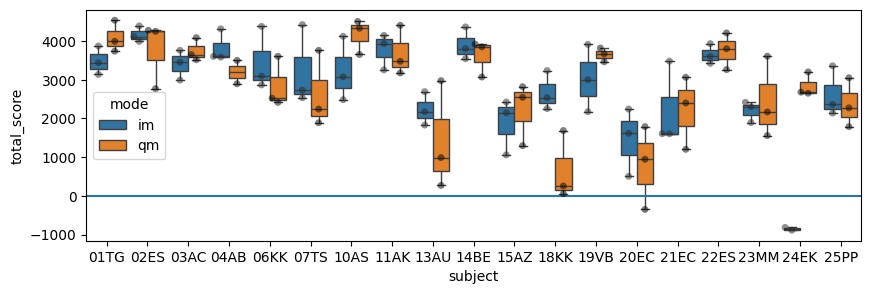

In [17]:
plt.figure(figsize=(10, 3))
metric = 'total_score'
sns.boxplot(df, x='subject', y=metric, hue='mode')
sns.swarmplot(df, x='subject', y=metric, hue='mode', dodge=True, s=5, alpha=.5, color='black', legend=False)
plt.axhline(0)

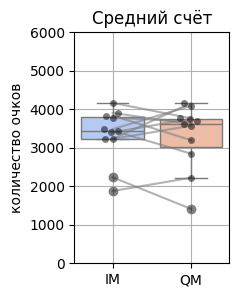

In [289]:
average_mode_plot(df_av, 'total_score', 0, 6000, 'Средний счёт', 'количество очков')

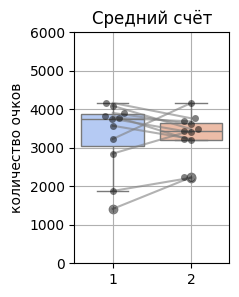

In [279]:
average_mode_plot(df_or, 'total_score', 0, 6000, 'Средний счёт', 'количество очков', x='order')

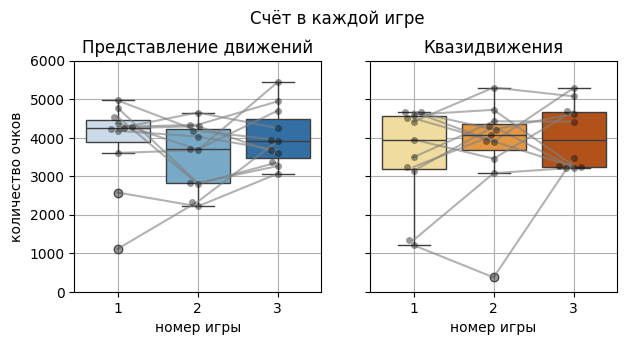

In [143]:
by_game_plot(df, 'total_score', 0, 6000, 'Счёт в каждой игре', 'количество очков')

### green steps per min

<Axes: xlabel='subject', ylabel='green_steps_min'>

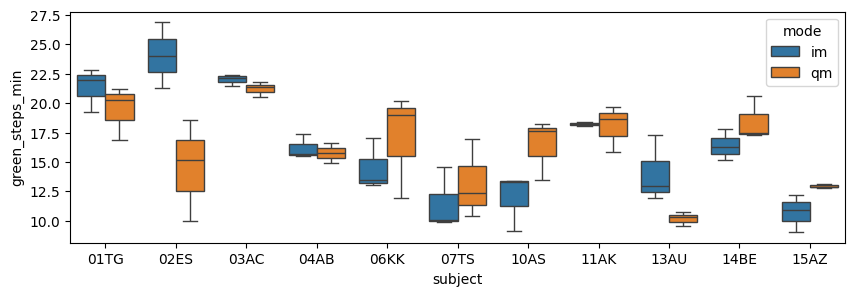

In [306]:
plt.figure(figsize=(10, 3))
metric ='green_steps_min'
sns.boxplot(df, x='subject', y=metric, hue='mode')

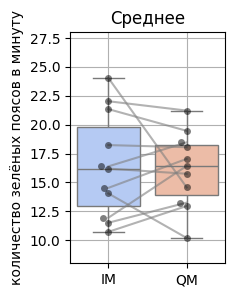

In [144]:
average_mode_plot(df_av, 'green_steps_min', 8, 28, 'Среднее','количество зелёных поясов в минуту')

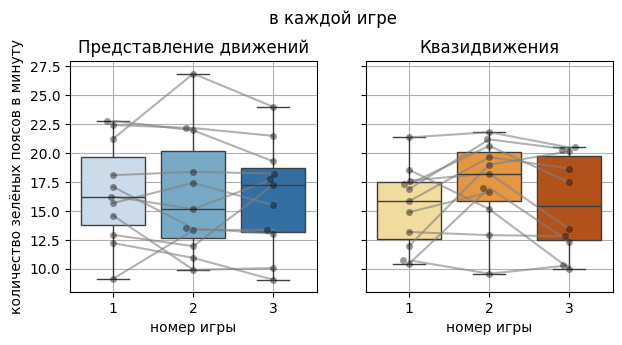

In [145]:
by_game_plot(df, 'green_steps_min', 8, 28, 'в каждой игре','количество зелёных поясов в минуту')

### n hh

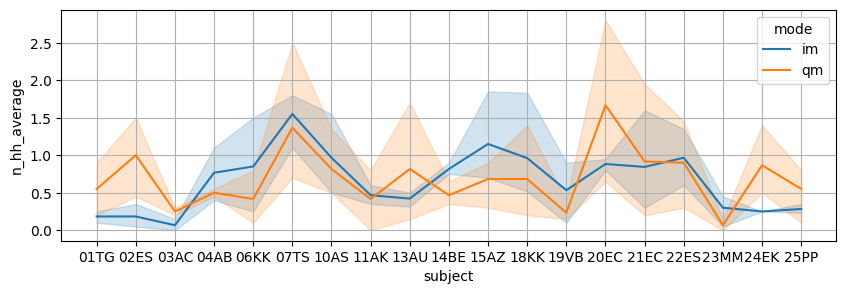

In [10]:
plt.figure(figsize=(10, 3))
metric ='n_hh_average'
# sns.boxplot(df, x='subject', y=metric, hue='mode')
# sns.swarmplot(df, x='subject', y=metric, hue='mode', dodge=True)
sns.lineplot(df, x='subject', y=metric, estimator=np.mean, hue='mode')
plt.grid();

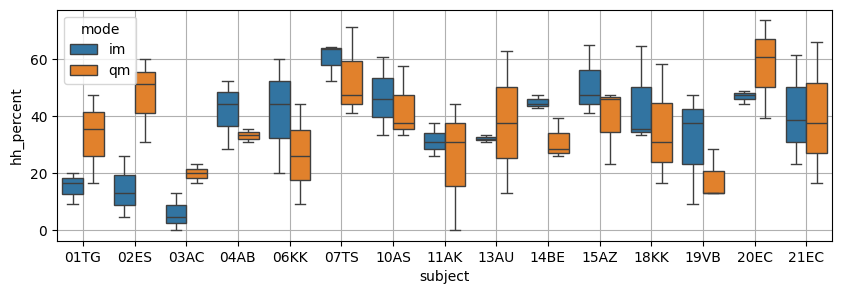

In [11]:
plt.figure(figsize=(10, 3))
metric ='hh_percent'
sns.boxplot(df, x='subject', y=metric, hue='mode')
plt.grid();

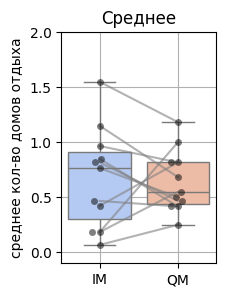

In [146]:
average_mode_plot(df_av, 'n_hh_average', -.1, 2, 'Среднее','среднее кол-во домов отдыха')

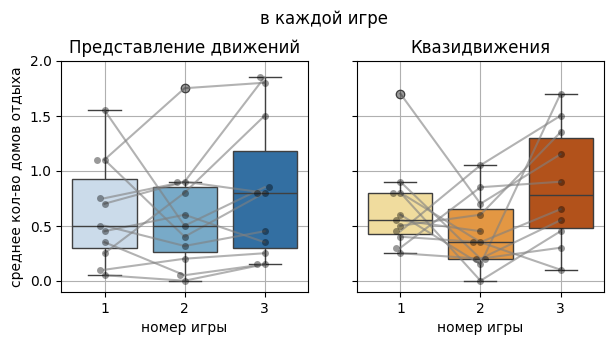

In [147]:
by_game_plot(df,'n_hh_average', -.1, 2, 'в каждой игре','среднее кол-во домов отдыха')

### percent of green steps

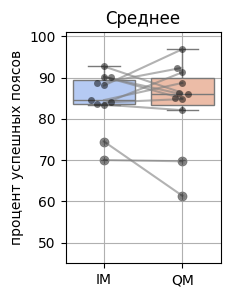

In [148]:
average_mode_plot(df_av, 'p_green_steps', 45, 101, 'Среднее','процент успешных поясов')

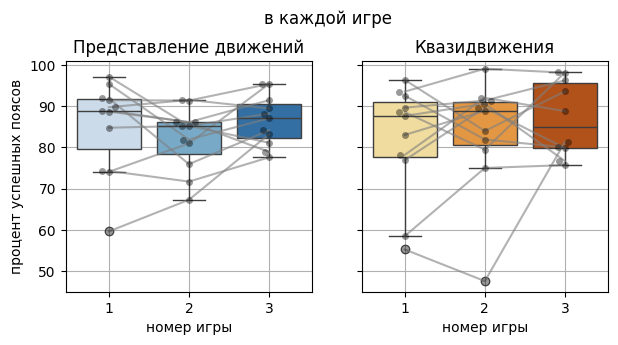

In [149]:
by_game_plot(df,'p_green_steps', 45, 101, 'в каждой игре','процент успешных поясов')

### overkill steps

<Axes: xlabel='subject', ylabel='n_overkill_average'>

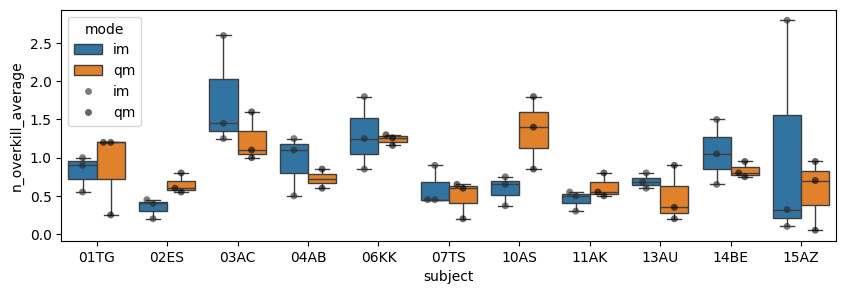

In [97]:
plt.figure(figsize=(10, 3))
metric ='n_overkill_average'
sns.boxplot(df, x='subject', y=metric, hue='mode')
sns.swarmplot(df, x='subject', y=metric, hue='mode', dodge=True, alpha=0.6, color='black')

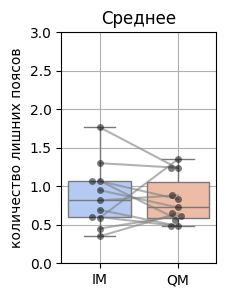

In [233]:
average_mode_plot(df_av, 'n_overkill_average', 0 ,3, 'Среднее','количество лишних поясов')

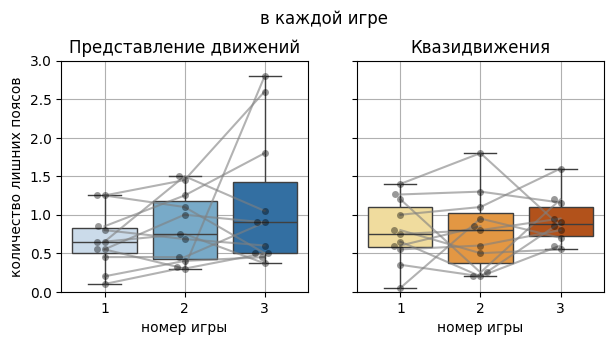

In [232]:
by_game_plot(df,'n_overkill_average', 0 ,3, 'в каждой игре','количество лишних поясов')

### p good steps

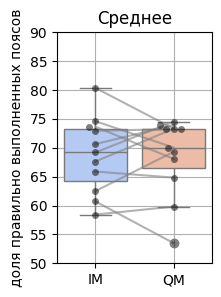

In [82]:
average_mode_plot(df_av, 'p_good_steps', 50, 90, 'Среднее','доля правильно выполненных поясов')

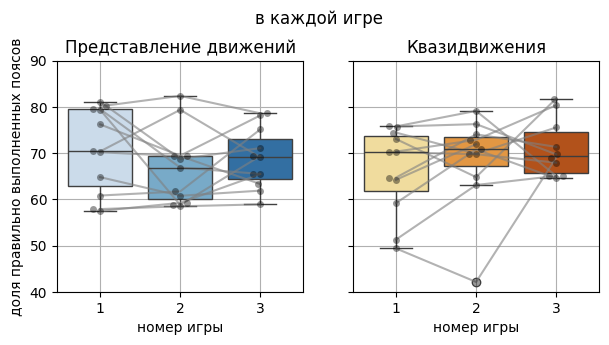

In [84]:
by_game_plot(df,'p_good_steps', 40, 90, 'в каждой игре','доля правильно выполненных поясов')

### averaged time

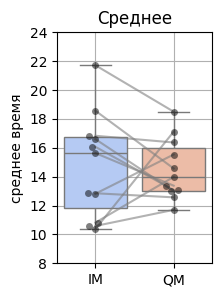

In [91]:
average_mode_plot(df_av, 'aver_time', 8, 24, 'Среднее','среднее время')

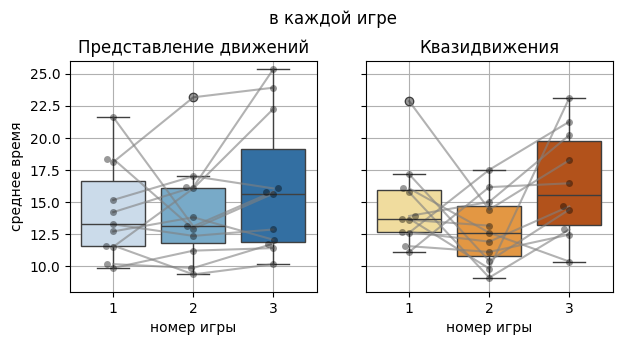

In [95]:
by_game_plot(df,'aver_time', 8, 26, 'в каждой игре','среднее время')

# clf metrics

## classifier calibration - reliability diagram

In [32]:
from sklearn.calibration import calibration_curve

In [29]:
df_proba = pd.read_csv(r'..\data\results\clf_dataset.csv')

In [33]:
subject = '01TG'
n_game = 1
df = df_proba.loc[(df_proba.subject == subject) & (df_proba.n_game == n_game)].copy()

In [40]:
steps = [f'step_{i}' for i in range(80)]
proba = []
for i in range(len(df)):
    star = df.iloc[i]
    if star.action != 'star_blasted':
        continue
    n_step1_nan = np.isnan(np.array([float(value) for value in star[steps].values])).sum() # 10 or 0 
    proba.extend(star[steps[n_step1_nan+10:-10]].values)
proba = np.array(proba)
proba

array([0.9392, 0.9823, 0.9851, ..., 0.9029, 0.8677, 0.8963])

In [42]:
calibration_curve(np.full(len(proba), fill_value=1), proba, n_bins=10)

(array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([0.03558667, 0.14955102, 0.25360172, 0.35183542, 0.45143443,
        0.55152532, 0.65057986, 0.75406538, 0.85776316, 0.95808311]))

## clf metrics

In [36]:
filename = r'..\data\results\clf_metrics_progress.csv'
df_clf = pd.read_csv(filename)
df_clf.rename(columns={'game': 'n_game'}, inplace=True)
df_clf.head()

,A,A_motor,proba_mean,latency_motor,latency_stop_forward,latency_stop_backward,stop_shift,stop_shift2,max_dur,n_onset,n_star,mode,n_game,subject
0,0.72,0.80,0.78,2090.0,500.0,500.0,-500.0,0.0,3900.0,2.0,0,im,1,01TG
1,0.61,0.77,0.69,1600.0,500.0,500.0,-500.0,-500.0,2400.0,2.0,1,im,1,01TG
2,0.64,0.86,0.85,2390.0,500.0,500.0,-500.0,-500.0,4400.0,1.0,2,im,1,01TG
3,0.90,1.00,0.96,1790.0,600.0,6800.0,600.0,600.0,6300.0,1.0,3,im,1,01TG
4,0.75,0.88,0.75,2590.0,500.0,500.0,-500.0,-100.0,4800.0,2.0,4,im,1,01TG


In [37]:
filename = r'..\data\results\clf_metrics_average.csv'
df_game = pd.read_csv(filename)
df_game.rename(columns={'game': 'n_game'}, inplace=True)
df_game.head()

,A,A_motor,proba_mean,latency_motor,latency_stop_forward,latency_stop_backward,stop_shift,stop_shift2,max_dur,n_onset,n_game,mode,subject
0,0.7565,0.8390,0.7980,1395.5,655.0,2700.0,130.0,260.0,4605.0,2.20,1,im,01TG
1,0.7510,0.8315,0.7865,707.5,720.0,2480.0,245.0,305.0,4995.0,2.35,2,im,01TG
2,0.7015,0.8110,0.7475,1581.0,880.0,3010.0,225.0,535.0,4430.0,2.10,3,im,01TG
3,0.7535,0.8645,0.7595,319.5,995.0,2035.0,25.0,400.0,4965.0,2.80,1,qm,01TG
4,0.7045,0.7655,0.6690,523.5,530.0,865.0,-120.0,-195.0,3935.0,3.20,2,qm,01TG


In [38]:
fl = r'..\data\results\stat\clf_metrics.xlsx'
df_game.to_excel(fl, index=False)

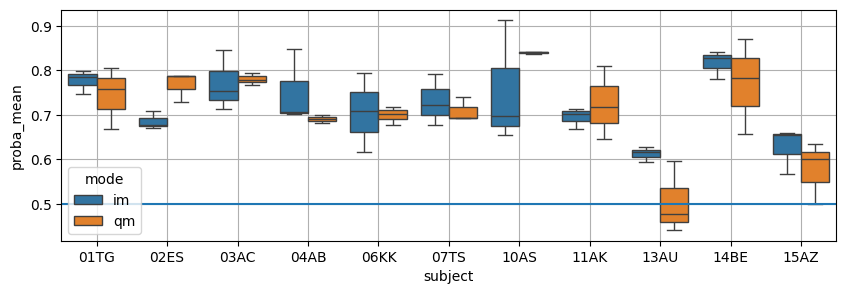

In [41]:
plt.figure(figsize=(10, 3))
sns.boxplot(df_game, x='subject', y='proba_mean', hue='mode')
plt.axhline(0.5)
plt.grid()

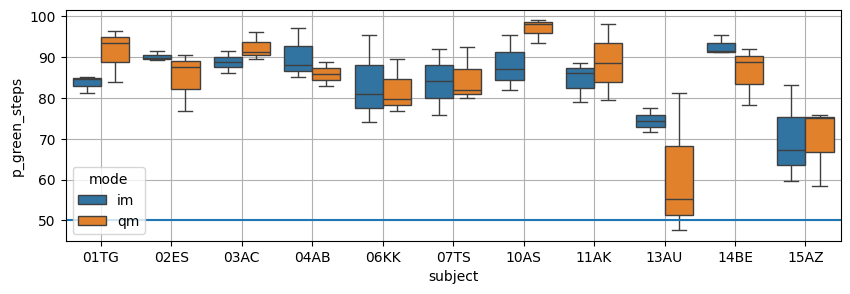

In [43]:
plt.figure(figsize=(10, 3))
sns.boxplot(df, x='subject', y='p_green_steps', hue='mode')
plt.axhline(50)
plt.grid()

In [39]:
df_av = []
for subject in df_game.subject.unique():
    for mode in ['im', 'qm']:
        df_average = df_game.loc[(df_game.subject == subject) & (df_game['mode'] == mode)].mean(numeric_only=True)
        df_average['subject'] = subject
        df_average['mode'] = mode
        df_av.append(df_average)
df_av = pd.DataFrame(df_av)

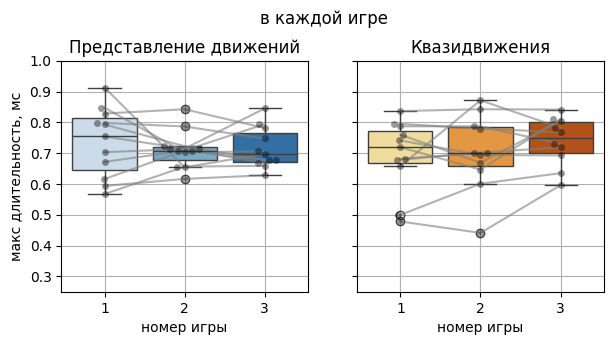

In [40]:
by_game_plot(df_game, 'proba_mean', 0.25, 1,  'в каждой игре','макс длительность, мс')

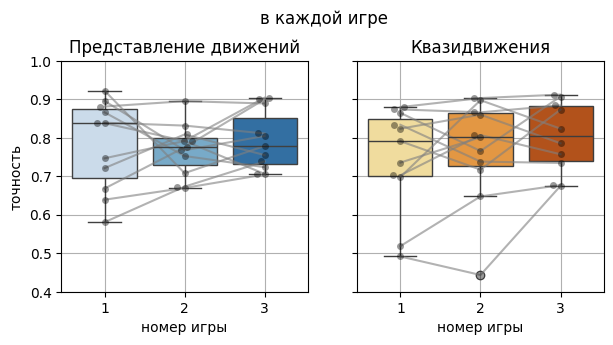

In [47]:
by_game_plot(df_game, 'A_motor', 0.4, 1,  'в каждой игре','точность')

### mean timecourse

In [315]:
df_proba = pd.read_csv(r'..\data\results\clf_dataset.csv')
df_proba = df_proba.loc[df_proba.action == 'star_blasted'].copy()

In [356]:
act, steps, overkill = [f'act_{i}' for i in range(10)], [f'step_{i}' for i in range(80)], [f'overkill_{i}' for i in range(40)]
df_median = []
for subject in df_proba.subject.unique():
    for mode in ['im', 'qm']:
        df_subj = df_proba.loc[(df_proba.subject == subject) & (df_proba['mode'] == mode)].copy()
        # df_all = []
        # for i in range(len(df_subj)):
        #     n_step1_nan = np.isnan(np.array([float(value) for value in df_subj[steps].iloc[i]values])).sum() # 10 or 0
        #     start_ind = n_step1_nan
        #     names = act + steps[n_step1_nan:] + overkill
        #     df_all.append(df_subj[names])
        # df_all = pd.Dat
        med = df_subj[act+steps+overkill].median()
        med['mode'] = mode
        med['subject'] = subject
        df_median.append(med)
df_median = pd.DataFrame(df_median)

(0.0, 1.0)

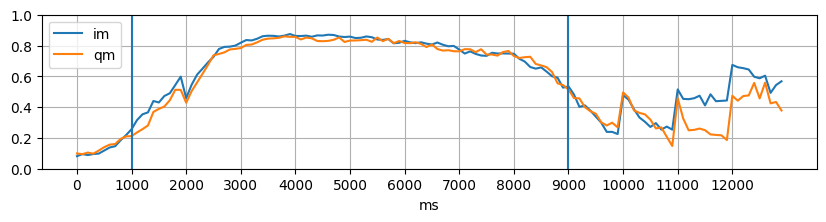

In [358]:
plt.figure(figsize=(10, 2))
for mode in ['im', 'qm']:
    mean = df_median.loc[df_median['mode'] == mode][act+steps+overkill].mean().values
    plt.plot(mean, label=mode)
plt.grid()
plt.legend()
plt.ylim(0, 1)
plt.axvline(10)
plt.axvline(90)
plt.xticks(np.arange(0, 130, 10), np.arange(0, 13000, 1000));
plt.xlabel('ms')
plt.ylim(0, 1)

(0.0, 1.0)

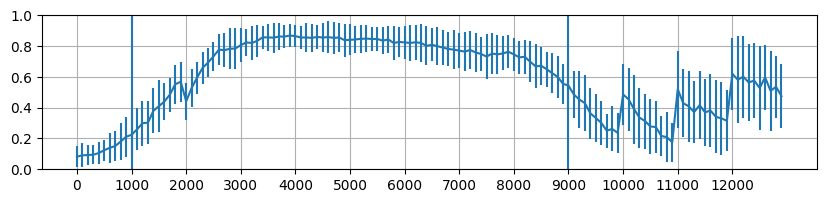

In [350]:
mean = df_median.mean().values
plt.figure(figsize=(10, 2))
plt.errorbar(x=np.arange(len(mean)), y=mean, yerr=df_median.std().values)
plt.grid()
plt.axvline(10)
plt.axvline(90)
plt.xticks(np.arange(0, 130, 10), np.arange(0, 13000, 1000));
plt.ylim(0, 1)

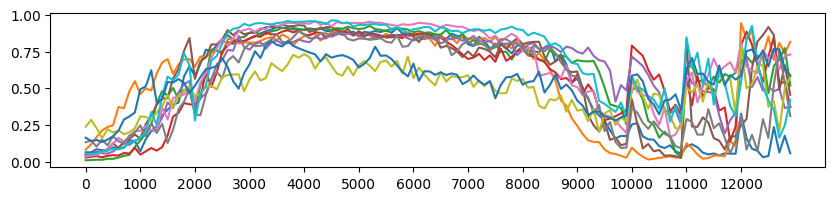

In [349]:
plt.figure(figsize=(10, 2))
for i in range(len(df_median)):
    plt.plot(df_median.iloc[i].values)
plt.xticks(np.arange(0, 130, 10), np.arange(0, 13000, 1000));

### max dur

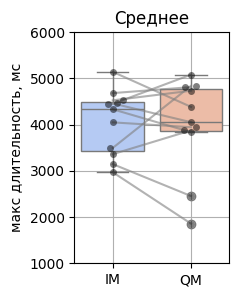

In [185]:
average_mode_plot(df_av, 'max_dur', 1000, 6000, 'Среднее','макс длительность, мс')

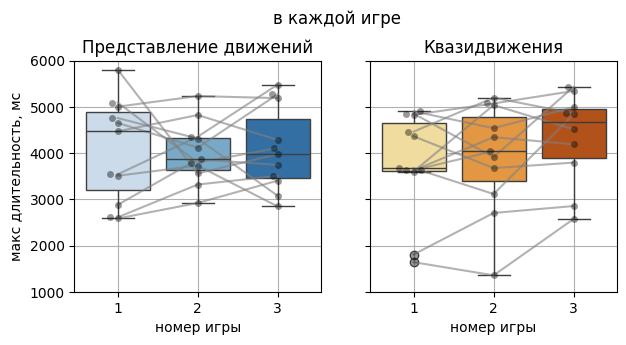

In [167]:
by_game_plot(df_game, 'max_dur', 1000, 6000,  'в каждой игре','макс длительность, мс')

### number of onsets

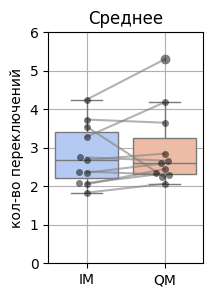

In [174]:
average_mode_plot(df_av, 'n_onset', 0, 6, 'Среднее','кол-во переключений')

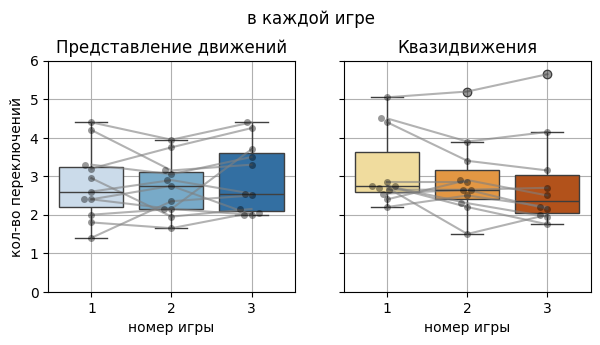

In [175]:
by_game_plot(df_game, 'n_onset', 0, 6,  'в каждой игре','кол-во переключений')

### stop shift

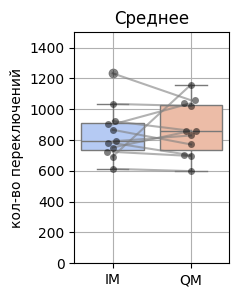

In [214]:
average_mode_plot(df_av, 'latency_stop_forward', 0, 1500, 'Среднее','кол-во переключений')

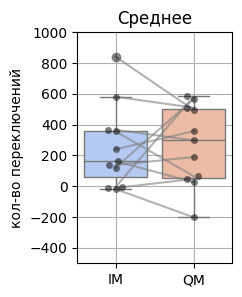

In [ ]:
average_mode_plot(df_av, 'stop_shift2', -500, 1000, 'Среднее','кол-во переключений')ы

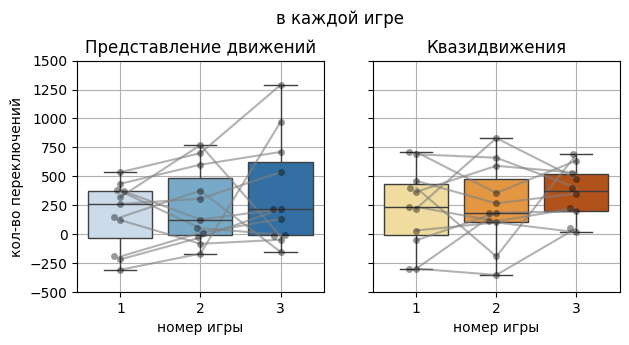

In [354]:
by_game_plot(df_game, 'stop_shift2', -500, 1500, 'в каждой игре','кол-во переключений')

In [237]:
df_av

,A,A_motor,latency_motor,latency_stop_forward,latency_stop_backward,stop_shift,stop_shift2,max_dur,n_onset,n_game,subject,mode
0,0.736333,0.606167,1228.000000,751.666667,2730.000000,200.000000,366.666667,4676.666667,2.216667,2.0,01TG,im
1,0.753667,0.626167,445.500000,860.000000,2048.333333,123.333333,298.333333,4846.666667,2.800000,2.0,01TG,qm
2,0.737167,0.558667,422.666667,613.333333,1445.000000,-78.333333,-11.666667,3603.333333,3.950000,2.0,02ES,im
3,0.771333,0.601833,452.833333,598.333333,1466.666667,-110.000000,48.333333,5001.666667,2.650000,2.0,02ES,qm
4,0.677667,0.621500,1261.666667,901.666667,2265.000000,8.333333,121.666667,4785.000000,2.633333,2.0,03AC,im
5,0.751333,0.640833,1078.000000,1040.000000,2290.000000,110.000000,566.666667,4910.000000,2.550000,2.0,03AC,qm
6,0.706167,0.606000,1177.333333,923.333333,2298.333333,96.666667,356.666667,4420.000000,2.850000,2.0,04AB,im
7,0.657500,0.567000,1227.000000,860.000000,1485.000000,-87.500000,65.000000,3915.000000,3.075000,2.0,04AB,qm
8,0.669333,0.575167,1418.333333,1233.333333,3021.666667,316.666667,841.666667,4613.333333,2.566667,2.0,06KK,im
9,0.657167,0.554333,1204.000000,1058.333333,2643.333333,465.000000,495.000000,4196.666667,2.766667,2.0,06KK,qm


In [104]:
def add_subject_info(df, mode, game, subject):
    df['mode'] = mode
    df['game'] = game
    df['subject'] = subject
    return df

In [118]:
filename = r'..\data\results\clf_metrics_progress.csv'
df_clf = pd.read_csv(filename)
df_clf.head()

,A,A_motor,latency_motor,latency_stop_forward,latency_stop_backward,stop_shift,max_dur,n_onset,n_star,mode,game,subject
0,0.72,0.57,1100.0,1300.0,1000.0,-1000.0,3900.0,2.0,0,im,1,01TG
1,0.61,0.57,1500.0,300.0,0.0,0.0,2400.0,2.0,1,im,1,01TG
2,0.64,0.61,1400.0,1600.0,1000.0,-1000.0,4400.0,1.0,2,im,1,01TG
3,0.90,0.71,1000.0,1600.0,1000.0,-1000.0,6000.0,1.0,3,im,1,01TG
4,0.75,0.63,1600.0,1300.0,1000.0,-1000.0,4500.0,2.0,4,im,1,01TG


<Axes: xlabel='subject', ylabel='stop_shift'>

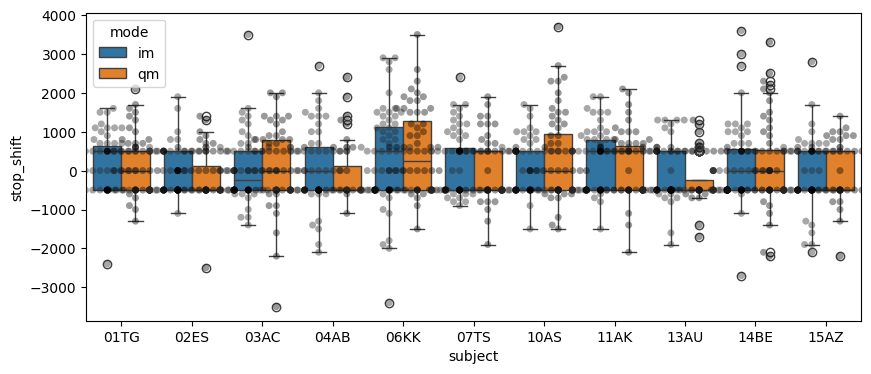

In [210]:
plt.figure(figsize=(10, 4))
df_curr = df_clf #.loc[df_clf.game==1]
metric = 'stop_shift'
sns.boxplot(df_curr, x='subject', y=metric, hue='mode')
sns.swarmplot(df_curr, x='subject', y=metric, hue='mode', dodge=True, color='black', alpha=0.4, legend=False)

<Axes: xlabel='subject', ylabel='n_onset'>

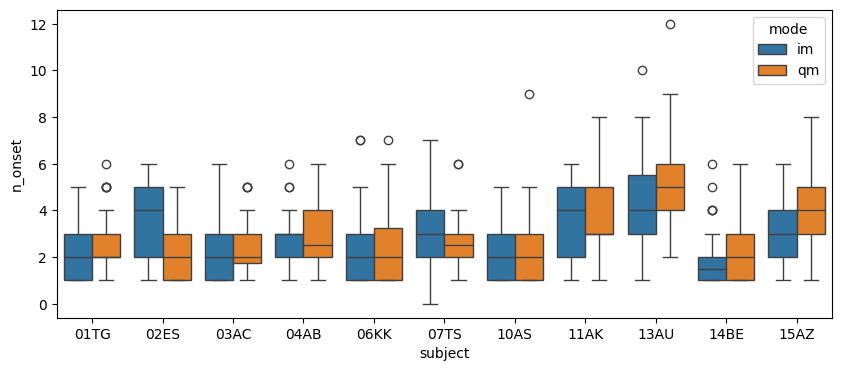

In [132]:
plt.figure(figsize=(10, 4))
df_curr = df_clf #.loc[df_clf.game==1]
sns.boxplot(df_curr, x='subject', y='n_onset', hue='mode')
# sns.swarmplot(df_curr, x='subject', y='n_onset', hue='mode', dodge=True, color='black', alpha=0.4, legend=False)

In [ ]:
metrics = ['latency_motor', 'stop_shift', 'max_dur', 'n_onset']
df_av = []
for subject in df_clf.subject.unique():
    for mode in ['im', 'qm']:
        for game in [1, 2, 3]:
            df_curr = df_clf.loc[(df_clf.subject == subject) & (df_clf['mode'] == mode) & (df_clf.game == game)]
            df_average = df_curr[metrics].mean().T
            df_average = add_subject_info(df_average, mode, game, subject)
            df_av.append(df_average)
df_av = pd.DataFrame(df_av)

In [129]:
metric = 'max_dur'
df_dur = []
for subject in df_clf.subject.unique():
    score = {'subject': subject}
    for mode in ['im', 'qm']:
        for game in [1, 2, 3]:
            df_curr = df_clf.loc[(df_clf.subject == subject) & (df_clf['mode'] == mode) & (df_clf.game == game)]
            mean, std = df_curr[metric].mean(), df_curr[metric].std()
            if np.isnan(mean):
                mean, std = 0, 0
            score[f'{mode}_{game}'] = f'{round(mean)}±{round(std)}'
    df_dur.append(score)
df_dur = pd.DataFrame(df_dur)

In [130]:
df_dur

,subject,im_1,im_2,im_3,qm_1,qm_2,qm_3
0,01TG,4470±1800,4825±1799,4285±1740,4855±1421,3915±1535,5435±1469
1,02ES,2880±1025,3865±1620,3745±1774,4465±1483,5200±1806,4860±2335
2,03AC,4655±1296,4120±1857,5275±1115,4905±1364,4540±1118,4995±1057
3,04AB,5095±1121,3795±1336,4110±1115,3630±1180,4045±1429,0±0
4,06KK,3540±1576,4355±1411,5485±1703,3625±1603,4345±1520,4190±1670
5,07TS,4760±1499,4315±1562,3075±1405,4365±1412,3675±1247,3795±1805
6,10AS,5810±1327,3560±1843,3980±1251,4830±1342,5075±1428,5345±1345
7,11AK,3510±1198,3730±1225,2845±829,3675±1378,3115±1350,4840±1329
8,13AU,2585±831,2921±1179,3405±1795,1640±588,1355±700,2575±1124
9,14BE,5005±1483,5235±1263,5190±1887,3600±1614,5040±1227,4515±1606


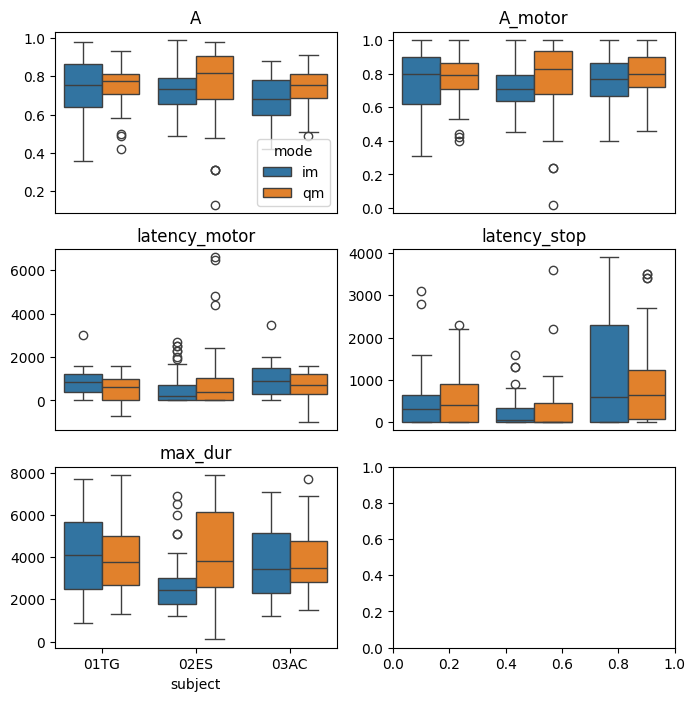

In [48]:
clf_metrics = ['A', 'A_motor', 'latency_motor', 'latency_stop', 'max_dur']
fig, ax = plt.subplots(3, 2, figsize=(8, 8))
for i in range(len(clf_metrics)):
    axis = ax[i//2][i%2]
    legend_status = False if i != 0 else True
    sns.boxplot(df_clf, x='subject', y=clf_metrics[i], hue='mode', ax=axis, legend=legend_status)
    if i < 4:
        axis.set_xticks([])
        axis.set_xlabel('')
    axis.set_ylabel('')
    axis.set_title(clf_metrics[i])